# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
# !pip install mat73 h5py

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [4]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser('~/ess-battery-project/data')

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : /Users/baejaeyeon/ess-battery-project/data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [5]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [6]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [7]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [8]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [9]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [10]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [11]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [12]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [14]:
# 0으로 위장한 결측치 찾기
print("0으로 기록된 값의 개수 :")
print((df[['QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']] == 0).sum())

0으로 기록된 값의 개수 :
QD            46
QC            46
IR            65
Tmax          46
Tavg          46
Tmin          46
chargetime    46
dtype: int64


In [16]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

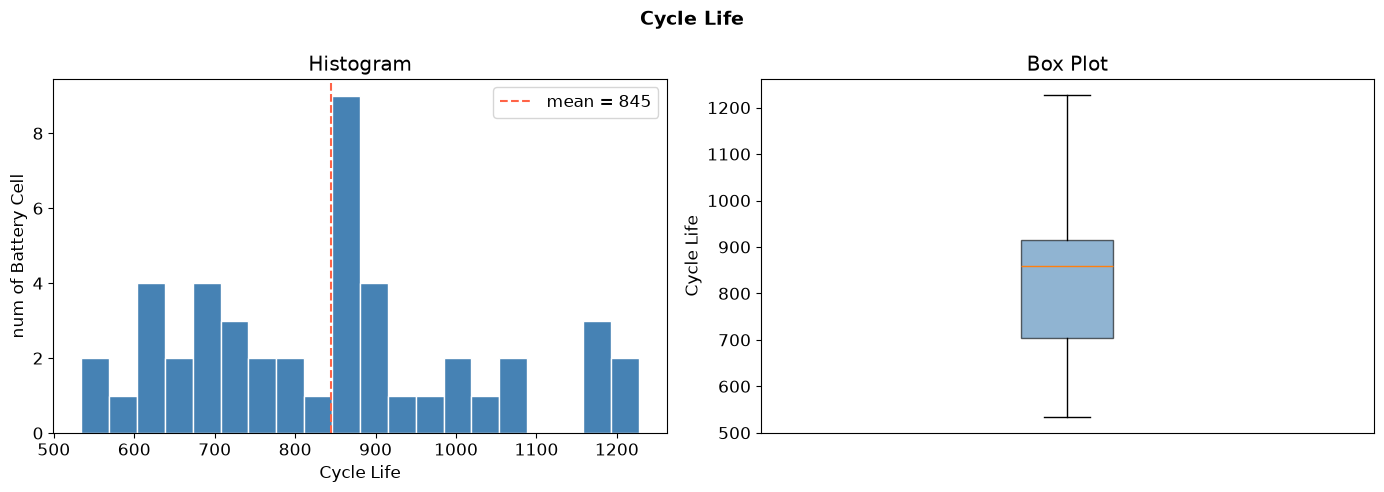

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [17]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

#### Q1 나의 정리


[describe]
- 배터리 셀 46개, 평균 수명 844.7 사이클 (최소 534 ~ 최대 1,227), 표준편차 184.6
- 평균(844.7) < 중앙값(858.5) : 차이 14로 작아 약한 왼쪽 치우침 수준, 큰 왜곡 없음
- IQR = 914.2 − 703.2 = 211.0 → 셀의 절반이 703 ~ 914 사이클에 집중
- 이상치 경계(1.5×IQR) = 386.7 ~ 1,230.7 → 통계적 이상치 셀 없음
  (단, max 1,227은 위쪽 경계와 3.7 차이로 경계에 근접)
- 장수명(>1,000) 10개(21.7%) / 단수명(<500) 0개(0%) / 중간 36개
- 분류 라벨 기준(550) 적용 시 : 단수명 1개 vs 장수명 45개
- 데이터 품질 : isnull() 결측치 0개이나, 각 셀의 cycle 1이 0으로 기록된
  위장 결측치 존재 (QD·온도·충전시간 46개, IR 65개)

[plot]
- Histogram : 단봉 정규분포가 아닌 세 무리 형태
  · 600~800 구간에 넓게 분포
  · 850~900 구간에 가장 많이 집중 (9개)
  · 1,150~1,230 구간에 떨어진 장수명 그룹 (5개)
  → 23종의 충전 방식(정책당 셀 2개)에 따라 수명이 그룹화된 것으로 추정 (Q4에서 검증)
- Box plot : 위쪽 수염(914→1,227, 313)이 아래쪽 수염(703→534, 169)보다 김
  → 장수명 쪽 편차가 더 크고 불규칙함

[to modeling]
- 학습 데이터(Batch 1)에 수명 500 미만 셀이 없음
  → 모델이 단수명 배터리를 학습하지 못함. Batch 2·3 분포와 비교 필요
- 분류(550 기준) 선택 시 1 : 45의 심한 클래스 불균형
  → Accuracy만으로 평가 불가, F1-Score 병행. 회귀/분류 선택의 근거로 활용
- 분포가 여러 무리로 나뉨 → 충전 방식을 반영한 피처 필요
- 장수명 구간 편차가 커 예측 난이도가 높음 → 잔차(residual) 분석 병행
- cycle 1(0값) 제외 후 피처 계산 (평균·분산 왜곡 방지)
- 셀 46개의 소표본 → 과적합 주의, 단순한 모델부터 검토

In [19]:
# 장수명/단수명 비율 코드 
cl = cycle_life_df['cycle_life']
print(f"장수명 (>1000) : {(cl > 1000).sum()}개 ({(cl > 1000).mean()*100:.1f}%)")
print(f"단수명 (<500)  : {(cl < 500).sum()}개 ({(cl < 500).mean()*100:.1f}%)")
print(f"중간 (500~1000): {((cl >= 500) & (cl <= 1000)).sum()}개")

장수명 (>1000) : 10개 (21.7%)
단수명 (<500)  : 0개 (0.0%)
중간 (500~1000): 36개


In [20]:
print(f"단수명 (<550) : {(cl < 550).sum()}개")
print(f"장수명 (>=550): {(cl >= 550).sum()}개")

단수명 (<550) : 1개
장수명 (>=550): 45개


### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

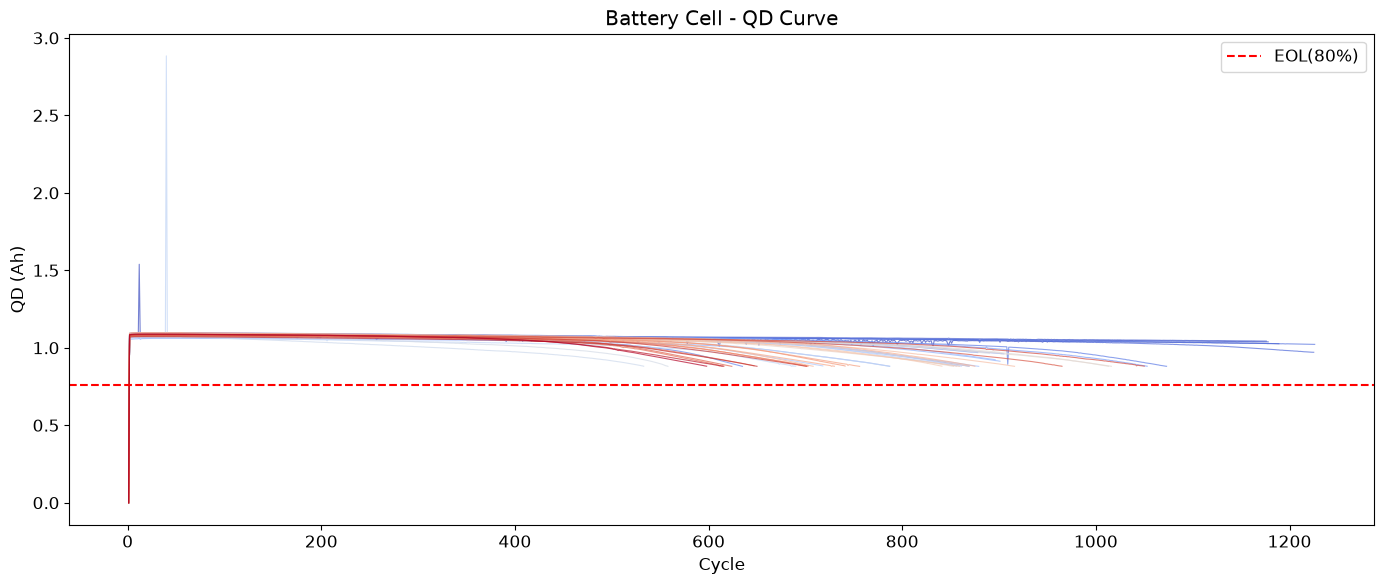

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

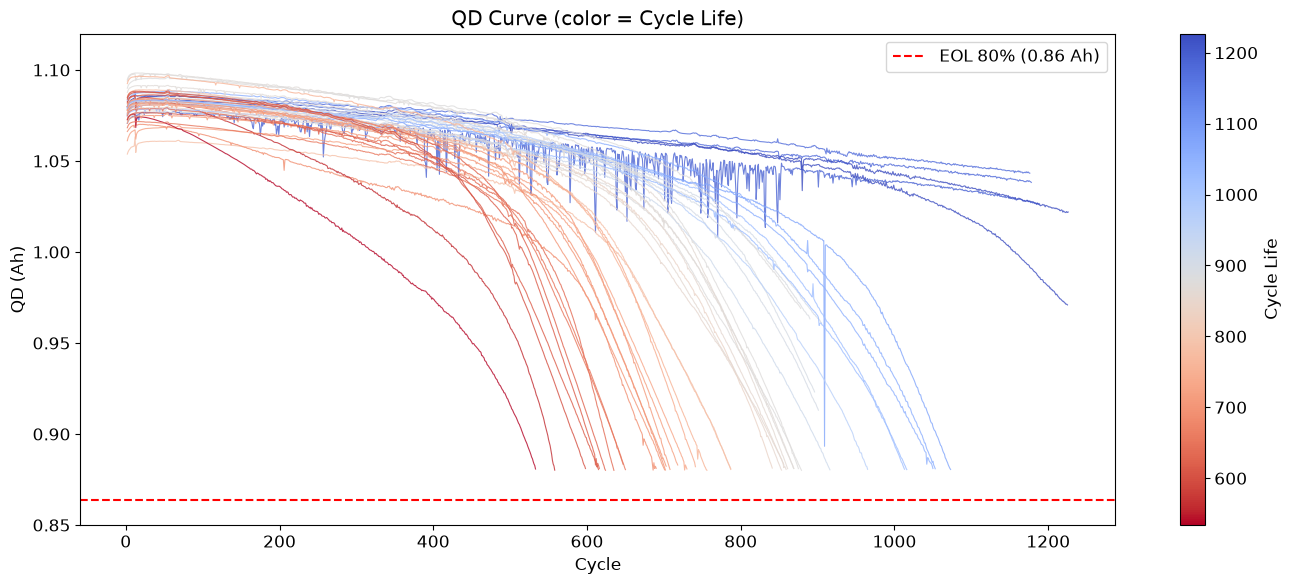

In [26]:
# 수명 기준으로 색칠한 열화 곡선 (파랑 = 장수, 빨강 = 단명)
life_map = df_clean.groupby('cell_id')['cycle_life'].first()
norm = plt.Normalize(life_map.min(), life_map.max())
cmap = cm.coolwarm_r

fig, ax = plt.subplots(figsize=(14, 6))
for cid, life in life_map.items():
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=cmap(norm(life)), linewidth=0.8, alpha=0.8)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--', label=f'EOL 80% ({nominal*0.8:.2f} Ah)')
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Cycle Life')
ax.set_xlabel('Cycle'); ax.set_ylabel('QD (Ah)')
ax.set_title('QD Curve (color = Cycle Life)')
ax.set_ylim(0.85, 1.12); ax.legend()
plt.tight_layout(); plt.show()

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


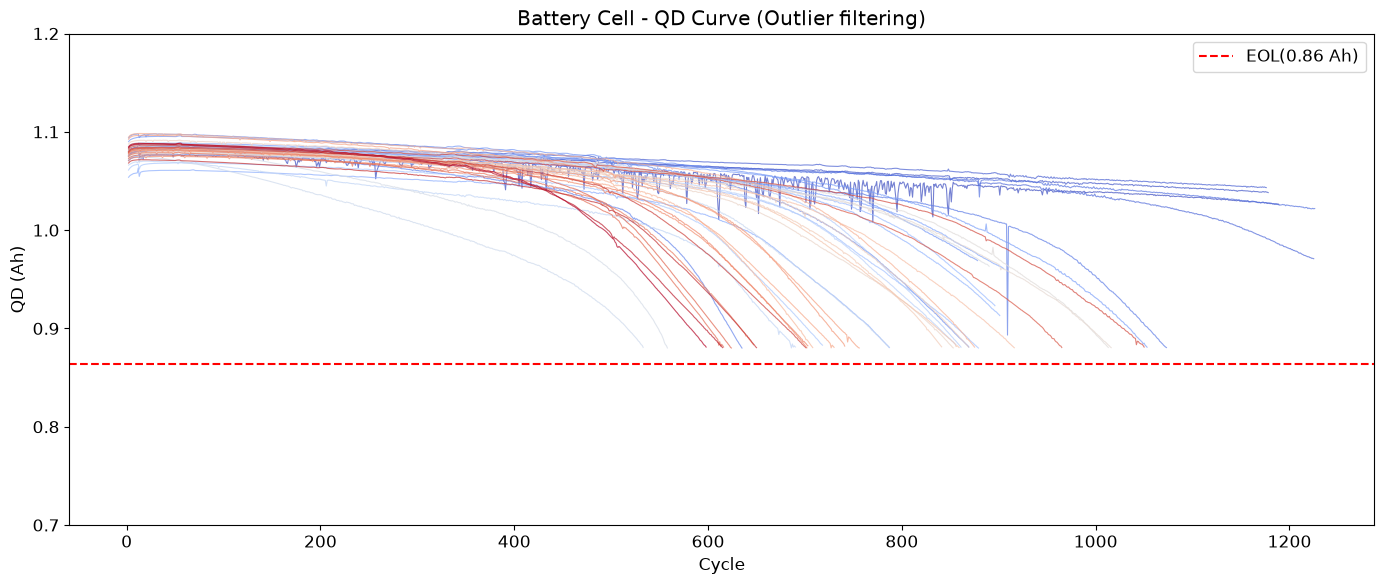

In [25]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

#### Q2 나만의 정리

[describe]
- 공칭 용량(초기 5사이클 중앙값) 1.0796 Ah, 정상 범위(0.8~1.2배) 밖 48행(0.12%) 제거
- cycle 1의 0값(위장 결측치)과 초기 스파이크(최대 2.884 Ah)는 측정 오류로 판단
- 초기 100사이클 평균 QD와 수명의 상관계수 0.193 → 약한 관계

[plot]
- 수명 기준 색상(빨강=단명, 파랑=장수)으로 그린 결과, 빨강→파랑 순서로 꺾이는 시점이 정렬됨
  · 단명 셀: 400~600 사이클부터 급격히 하락
  · 장수 셀: 800~1,000 사이클부터 급격히 하락
- 모든 셀에서 완만한 감소 후 급격히 꺾이는 Knee point 형태 확인 → 열화 속도가 가속됨(비선형)
- 초기 0~100 사이클은 모든 셀이 1.06~1.10 Ah에 겹쳐 수명별 구분이 어려움
- 수명 1,150 이상 셀 5개는 EOL(0.88 Ah)에 도달하지 않고 1.02~1.04 Ah에서 기록 종료
  → 실험 중단으로 실제 수명보다 짧게 기록되었을 가능성
- 원본 코드의 EOL 기준선은 cycle 1의 0값이 평균에 섞여 0.76 Ah로 잘못 표시됨 → 중앙값 기반으로 수정

[to modeling]
- 초기 용량 값(QD)만으로는 수명 예측력이 약함 → ΔQ(V) 곡선의 형태 변화 등 새로운 피처 필요 (Q3)
- 열화가 비선형(Knee) → 선형 관계만 가정하지 말고 비선형 모델 또는 로그 변환 검토
- EOL 미도달 셀 5개의 cycle_life는 신뢰도가 낮음 → 학습 포함 여부 검토, 데이터 한계로 명시
- 이상치·0값은 피처 계산 전에 제거 (평균은 중앙값 기반으로 처리)

### 3. 내부 저항(IR) 변화 - 열화 지표

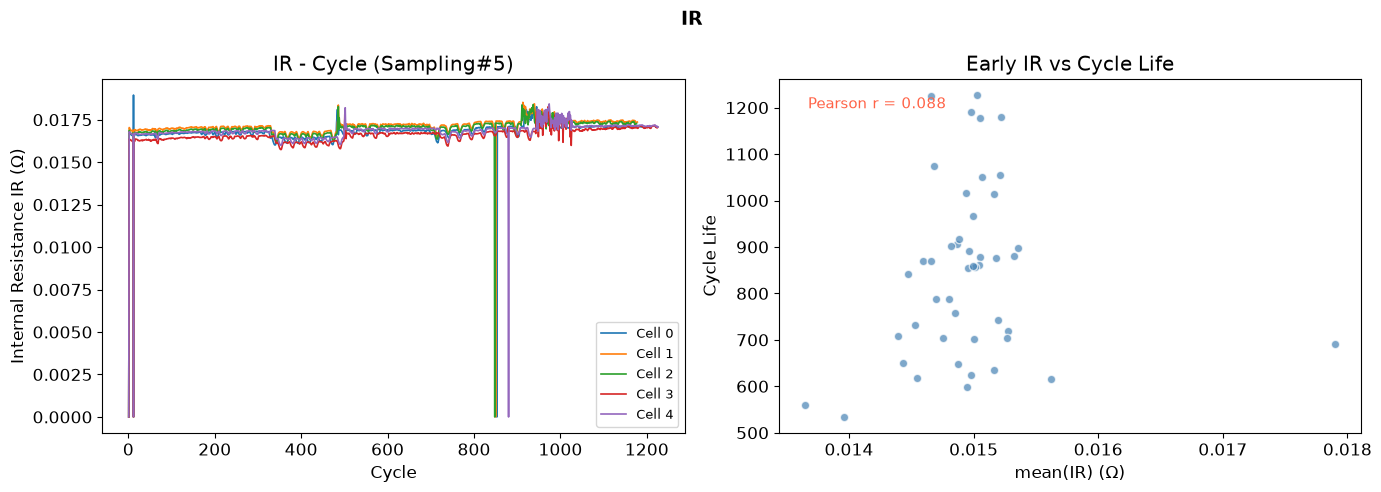

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

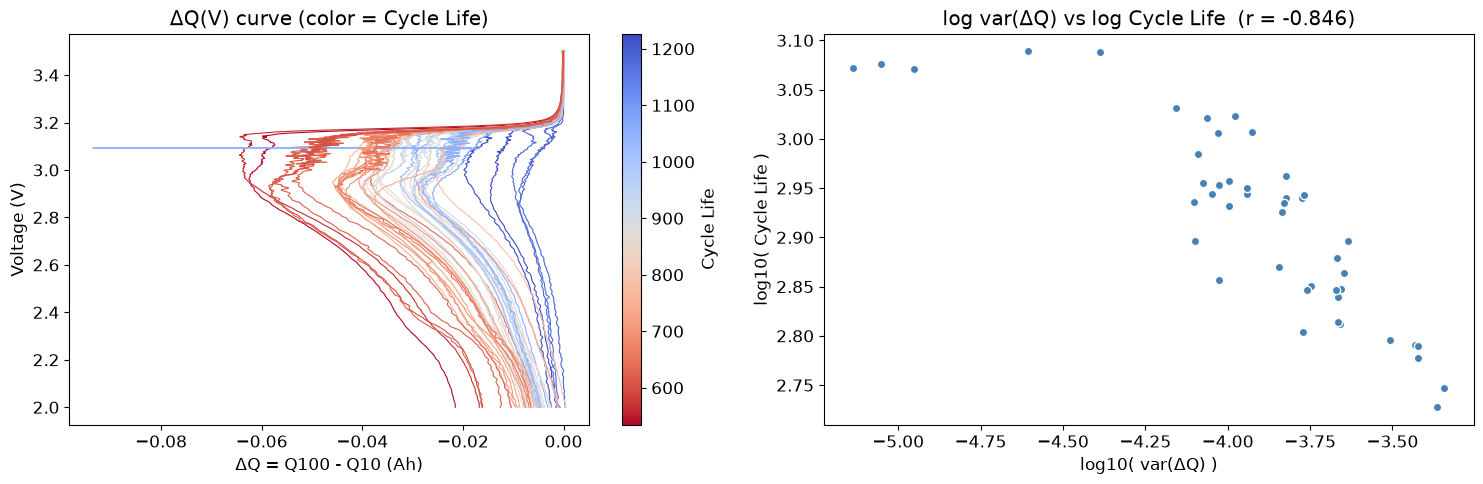

계산된 셀 수 : 46
상관계수 r (log var ΔQ vs log cycle life) : -0.846


In [29]:
# Q3. ΔQ(V) = Q100(V) - Q10(V)
rows, dq_curves = [], {}
for i, cell in enumerate(batch):
    q10  = cell['cycles']['Qdlin'][10]
    q100 = cell['cycles']['Qdlin'][100]
    if q10 is None or q100 is None:
        continue
    dq = np.asarray(q100, float) - np.asarray(q10, float)
    dq_curves[i] = dq
    rows.append({'cell_id': i,
                 'cycle_life': float(cell['cycle_life']),
                 'dq_var': np.var(dq), 'dq_min': np.min(dq), 'dq_mean': np.mean(dq)})

dq_df = pd.DataFrame(rows)
dq_df['log_dq_var']     = np.log10(dq_df['dq_var'])
dq_df['log_cycle_life'] = np.log10(dq_df['cycle_life'])
V = np.asarray(batch[0]['Vdlin'], float)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
norm = plt.Normalize(dq_df['cycle_life'].min(), dq_df['cycle_life'].max())
for _, r in dq_df.iterrows():
    axes[0].plot(dq_curves[r['cell_id']], V, color=cm.coolwarm_r(norm(r['cycle_life'])), lw=0.8)
axes[0].set_xlabel('ΔQ = Q100 - Q10 (Ah)'); axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('ΔQ(V) curve (color = Cycle Life)')
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.coolwarm_r), ax=axes[0], label='Cycle Life')

r = dq_df['log_dq_var'].corr(dq_df['log_cycle_life'])
axes[1].scatter(dq_df['log_dq_var'], dq_df['log_cycle_life'], color='steelblue', edgecolors='white')
axes[1].set_xlabel('log10( var(ΔQ) )'); axes[1].set_ylabel('log10( Cycle Life )')
axes[1].set_title(f'log var(ΔQ) vs log Cycle Life  (r = {r:.3f})')
plt.tight_layout(); plt.show()

print(f"계산된 셀 수 : {len(dq_df)}")
print(f"상관계수 r (log var ΔQ vs log cycle life) : {r:.3f}")

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

#### Q3 나만의 정리 
[describe]
- ΔQ(V) = Q100(V) − Q10(V) : 100번째와 10번째 사이클의 방전 용량 곡선 차이 (Qdlin, 1,000포인트)
- 셀별 요약 통계량으로 var(ΔQ), min(ΔQ), mean(ΔQ) 추출
- log10(var(ΔQ)) vs log10(cycle_life) 상관계수 r = −0.846
  (비교 : 초기 100사이클 평균 QD vs 수명 r = 0.193)

[plot]
- ΔQ(V) 곡선 : 단명 셀(빨강)일수록 곡선이 음의 방향으로 크게 휘고, 장수 셀(파랑)은 0 근처에 위치
  → 초기 90사이클 동안 방전 특성이 많이 변한 셀일수록 수명이 짧음
- 총 용량(QD)으로는 구분되지 않던 셀들이 ΔQ(V) 곡선 형태로는 수명 순서대로 분리됨
- log-log 산점도 : 뚜렷한 음의 선형 관계
- 좌상단 5개 점은 선형 관계에서 이탈 → EOL 미도달 셀(Q2)과 일치, 수명 기록 신뢰도 낮음
- 3.09V 부근 비정상 가로선 1개 → 측정 이상 후보

[to modeling]
- log10(var(ΔQ))를 핵심 피처로 채택 (원논문의 핵심 피처와 일치)
- 분산 값은 매우 작고 치우쳐 있음 → 로그 변환으로 선형 관계 확보
  → 선형 계열 모델(Linear, Ridge, Lasso, ElasticNet)에 적합
- 타깃도 log10(cycle_life)로 변환 시 관계가 더 선형적
- EOL 미도달 셀 5개 처리 방안 결정 필요 (제외 또는 별도 표시)
- 초기 100사이클만 사용 → 실제 ESS에서 조기 수명 예측 가능성 확인

### 4. 충전 정책(C-rate)과 수명의 관계

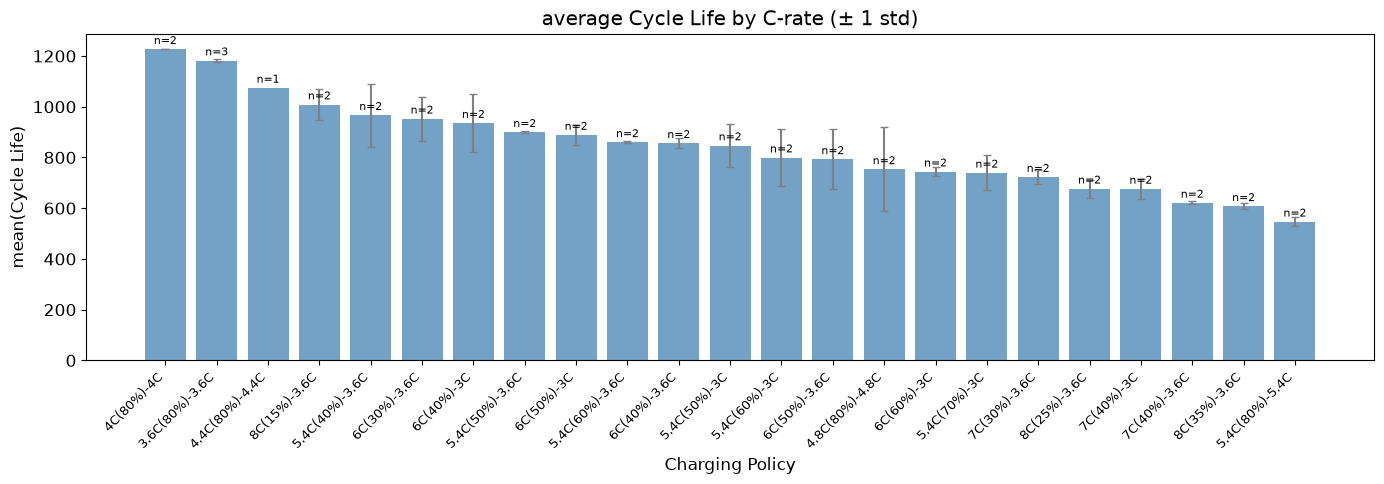

In [30]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

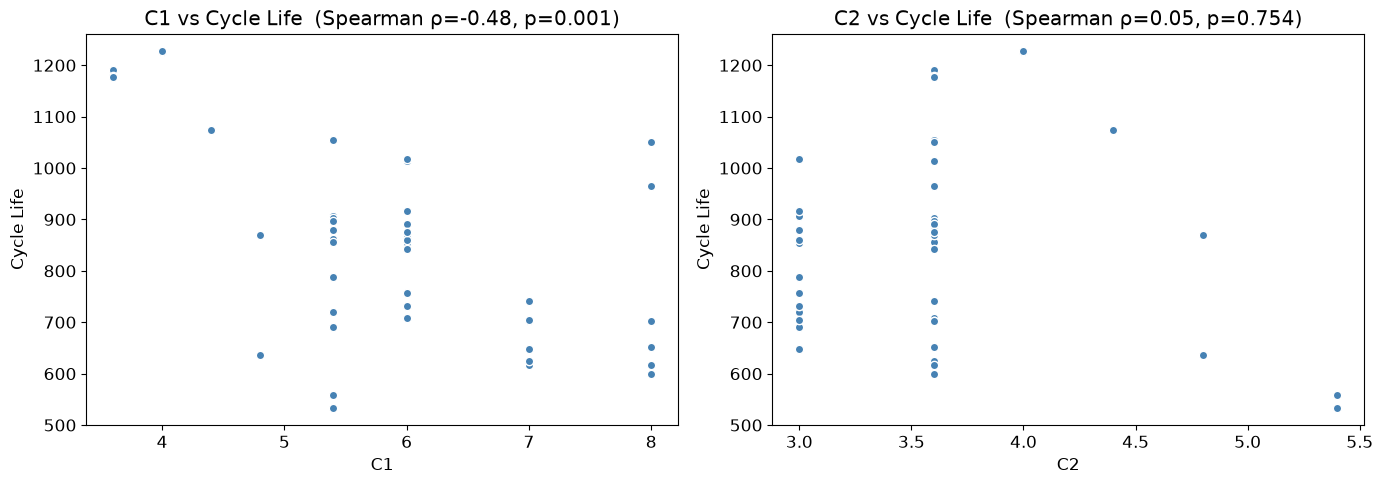

C1        0
Q1_pct    0
C2        0
dtype: int64


In [31]:
import re
from scipy.stats import spearmanr

def parse_policy(p):
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', str(p))
    return (float(m[1]), float(m[2]), float(m[3])) if m else (np.nan, np.nan, np.nan)

pol = cycle_life_df.copy()
pol[['C1', 'Q1_pct', 'C2']] = pol['charging_policy'].apply(lambda p: pd.Series(parse_policy(p)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, name in zip(axes, ['C1', 'C2'], ['1단계 C-rate', '2단계 C-rate']):
    rho, p = spearmanr(pol[col], pol['cycle_life'], nan_policy='omit')
    ax.scatter(pol[col], pol['cycle_life'], color='steelblue', edgecolors='white')
    ax.set_xlabel(col); ax.set_ylabel('Cycle Life')
    ax.set_title(f'{col} vs Cycle Life  (Spearman ρ={rho:.2f}, p={p:.3f})')
plt.tight_layout(); plt.show()

print(pol[['C1', 'Q1_pct', 'C2']].isna().sum())

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

#### Q4 나만의 정리 
[describe]
- Batch 1 충전 방식 23종, 방식당 셀 1~3개 (대부분 2개)
- 충전 방식 문자열(명목척도)에서 C1(1단계 C-rate), Q1%(전환 시점), C2(2단계 C-rate) 수치 추출
- Spearman 상관 : C1 vs 수명 ρ = −0.48 (p = 0.001, 유의), C2 vs 수명 ρ = 0.05 (p = 0.754, 유의하지 않음)

[plot]
- 막대그래프 : 낮은 C-rate일수록 수명이 길고, 높은 C-rate로 오래 충전할수록 짧음
  · 최하위 5.4C(80%)-5.4C (약 545) : 처음부터 끝까지 고속 충전
  · 8C(15%)-3.6C (약 1,000) : 최고 속도지만 15%만 고속 → 상위권
  → 고속 충전 속도뿐 아니라 고속으로 충전한 구간(%)이 함께 영향
- 상위 1·2위(4C(80%)-4C, 3.6C(80%)-3.6C)는 EOL 미도달 셀 5개와 일치 → 실제 수명은 더 길 가능성
- 동일 방식 내 편차가 큰 경우 존재 (4.8C(80%)-4.8C, ±165) → 셀 간 제조 편차
- 산점도 : C1이 커질수록 수명 감소 경향, C2는 뚜렷한 경향 없음

[to modeling]
- 충전 방식은 수명에 영향 → 이름(명목) 그대로 Dummy 변환하면 23개 컬럼 생성(셀 46개 대비 과다)
  → C1, Q1% 등 수치형 피처로 변환하여 사용
- 같은 방식 내 편차 존재 → 충전 방식만으로는 부족, ΔQ(V) 같은 셀 고유 신호와 결합 필요
- 방식당 표본 1~3개 → 경향성 수준으로 해석
- 같은 방식의 셀이 train/valid에 나뉘면 누수 위험 → 셀 단위 Hold-out 시 방식 분포 고려

### 5. 상관관계 히트맵

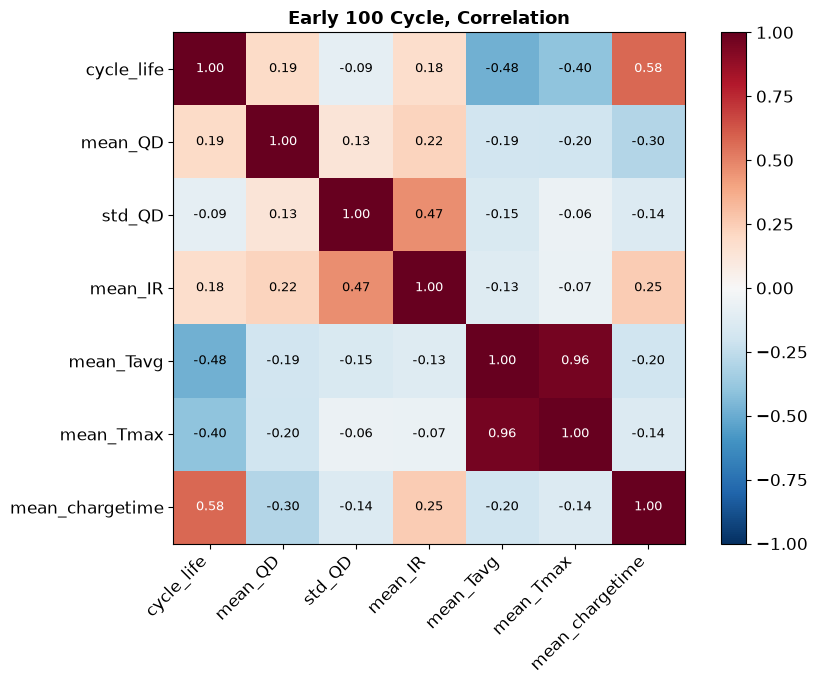


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [32]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

In [33]:
# Q5 개선 : 0값 제거 + Q3/Q4 피처 포함
clean = df[(df['cycle'] >= 2) & (df['cycle'] <= 100) & (df['QD'] > 0) & (df['IR'] > 0)]
early2 = clean.groupby('cell_id').agg(
    mean_QD=('QD', 'mean'), std_QD=('QD', 'std'), mean_IR=('IR', 'mean'),
    mean_Tavg=('Tavg', 'mean'), mean_Tmax=('Tmax', 'mean'),
    mean_chargetime=('chargetime', 'median')).reset_index()

feat = (early2.merge(dq_df[['cell_id', 'cycle_life', 'log_dq_var']], on='cell_id')
              .merge(pol[['cell_id', 'C1']], on='cell_id'))

corr2 = feat.drop(columns='cell_id').corr(method='spearman')
print("[cycle_life 상관 순위 (Spearman, 0값 제거)]")
print(corr2['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))
print(f"\nTavg vs Tmax : {corr2.loc['mean_Tavg','mean_Tmax']:.2f}")
print(f"std_QD vs mean_IR : {corr2.loc['std_QD','mean_IR']:.2f}")

[cycle_life 상관 순위 (Spearman, 0값 제거)]
log_dq_var        -0.853
mean_chargetime    0.641
C1                -0.483
mean_Tavg         -0.371
mean_Tmax         -0.323
mean_IR            0.189
mean_QD            0.185
std_QD             0.051
Name: cycle_life, dtype: float64

Tavg vs Tmax : 0.95
std_QD vs mean_IR : 0.02


#### Q5 나만의 정리 
[describe]
- 초기 100사이클(cycle 2~100, 0값 제거) 셀별 요약 피처와 Q3·Q4 피처의 Spearman 상관 분석
- cycle_life와의 상관 순위 :
  log10(var ΔQ) −0.853 > 충전시간 +0.641 > C1 −0.483 > 평균온도 −0.371 > 최고온도 −0.323
  > IR +0.189 ≈ 평균 QD +0.185 > std QD +0.051
- 다중공선성 : mean_Tavg ↔ mean_Tmax = 0.95
- 데이터 정제 효과 : std_QD ↔ mean_IR 상관이 0값 포함 시 0.47 → 제거 후 0.02
  → 원본의 관계는 위장 결측치(cycle 1 = 0)가 만든 가짜 상관

[plot]
- 히트맵 : 충전시간(+), 온도(−)가 수명과 중간 수준 상관, 용량·저항은 약한 상관
- Tavg-Tmax 블록이 진하게 표시 → 사실상 같은 정보

[to modeling]
- 핵심 피처 : log10(var ΔQ) (단일 피처로 가장 강한 신호)
- 보조 피처 : 충전시간, C1(충전 조건), 평균온도(발열)
- 다중공선성 대응 : Tavg와 Tmax 중 Tavg만 사용, 또는 Ridge/Lasso/ElasticNet 정규화로 제어
- 용량(QD)·저항(IR)의 단순 평균은 예측력이 약함 → 제외 또는 변화량 형태로 재설계
- 모든 피처는 0값·이상치 제거 후 계산 (가짜 상관 방지)

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

## Batch2 & Batch3

In [34]:
import gc

def to_cells(b):
    if isinstance(b, dict):
        keys = list(b.keys()); n = len(b[keys[0]])
        b = [{k: b[k][j] for k in keys} for j in range(n)]
    return b

def cell_level(batch_list, name):
    rows = []
    for i, cell in enumerate(batch_list):
        try:    life = float(np.asarray(cell['cycle_life']).squeeze())
        except: life = np.nan
        policy = cell.get('policy_readable') or cell.get('policy') or 'unknown'
        s, qdlin = cell['summary'], cell['cycles']['Qdlin']
        ldv = np.nan
        if len(qdlin) > 100 and qdlin[10] is not None and qdlin[100] is not None:
            dq = np.asarray(qdlin[100], float) - np.asarray(qdlin[10], float)
            ldv = np.log10(np.var(dq))
        tavg = np.asarray(s['Tavg'], float)[1:100]
        ct   = np.asarray(s['chargetime'], float)[1:100]
        rows.append(dict(batch=name, cell_id=i, cycle_life=life, policy=str(policy),
                         log_dq_var=ldv,
                         mean_Tavg=np.nanmean(np.where(tavg > 0, tavg, np.nan)),
                         med_chargetime=np.nanmedian(np.where(ct > 0, ct, np.nan))))
    return pd.DataFrame(rows)

# Batch 1 : 이미 메모리에 있음
cells = [cell_level(batch, 'Batch1')]
del mat; gc.collect()

# Batch 2, 3 : 하나씩 불러와서 요약만 남기고 바로 삭제
for name, f in [('Batch2', '2018-02-20_batchdata_updated_struct_errorcorrect.mat'),
                ('Batch3', '2018-04-12_batchdata_updated_struct_errorcorrect.mat')]:
    print(f"\n▶ {name} 로딩 중...")
    b = to_cells(load_mat(os.path.join(DATA_DIR, f))['batch'])
    cells.append(cell_level(b, name))
    del b; gc.collect()

all_cells = pd.concat(cells, ignore_index=True)
all_cells.to_csv(os.path.join(DATA_DIR, 'cells_all_batches.csv'), index=False)

print("\n===== 완료 =====")
print(all_cells.groupby('batch').agg(셀수=('cell_id', 'count'),
                                    수명없음=('cycle_life', lambda x: x.isna().sum()),
                                    ΔQ없음=('log_dq_var', lambda x: x.isna().sum())))

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro


▶ Batch2 로딩 중...


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3 / HDF5 형식)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro


▶ Batch3 로딩 중...


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3 / HDF5 형식)

===== 완료 =====
        셀수  수명없음  ΔQ없음
batch                 
Batch1  46     0     0
Batch2  47     8     0
Batch3  46     2     0


[Q1] Cycle Life 분포 비교
        count    mean    std    min    25%     50%     75%     max
batch                                                             
Batch1   46.0   844.7  184.6  534.0  703.2   858.5   914.2  1227.0
Batch2   39.0   565.7  222.2  392.0  439.5   472.0   508.5  1186.0
Batch3   44.0  1059.7  313.9  541.0  828.0  1005.5  1155.2  1935.0
       장수명_1000초과 단수명_500미만 단수명_550미만
batch                                
Batch1      21.7%      0.0%        1개
Batch2       7.7%     71.8%       30개
Batch3      52.3%      0.0%        1개

[Q3~Q5] 배치별 Spearman 상관 (vs cycle_life)
        log_dq_var  chargetime   Tavg
batch                                
Batch1      -0.853       0.641 -0.371
Batch2      -0.716      -0.812  0.166
Batch3      -0.800       0.261  0.025

[Q4] 충전 방식 수 : Batch1 23종, Batch2 12종, Batch3 8종
Batch1 ∩ Batch2 공통 방식 : 2종
Batch1 ∩ Batch3 공통 방식 : 0종


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

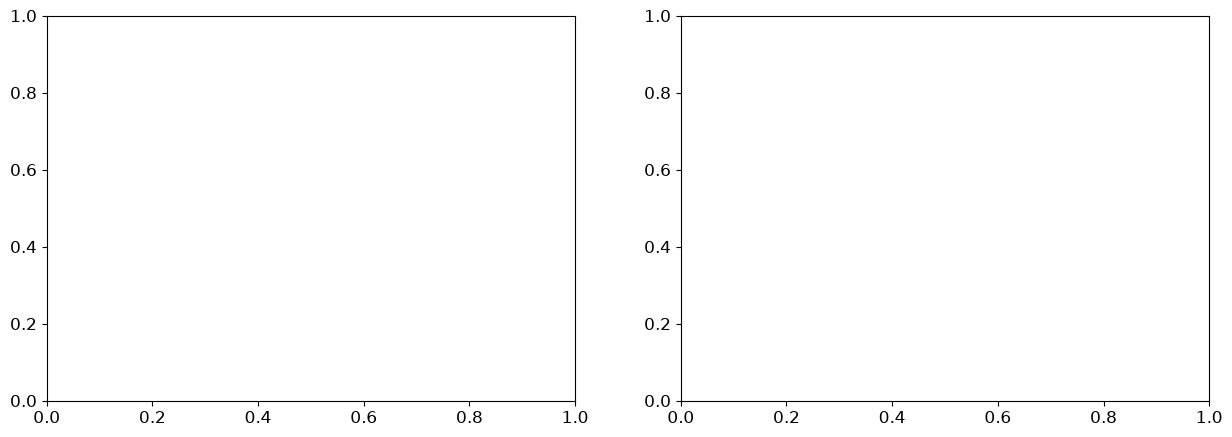

In [38]:
from scipy.stats import spearmanr
ac = all_cells.dropna(subset=['cycle_life']).copy()
ac = ac[np.isfinite(ac['log_dq_var'])]
ac['log_life'] = np.log10(ac['cycle_life'])
colors = {'Batch1': 'tab:blue', 'Batch2': 'tab:orange', 'Batch3': 'tab:green'}

# ── Q1. 분포 비교 ──
print("[Q1] Cycle Life 분포 비교")
print(ac.groupby('batch')['cycle_life'].describe().round(1))
ratio = ac.groupby('batch')['cycle_life'].agg(
    장수명_1000초과=lambda x: f"{(x>1000).mean()*100:.1f}%",
    단수명_500미만=lambda x: f"{(x<500).mean()*100:.1f}%",
    단수명_550미만=lambda x: f"{(x<550).sum()}개")
print(ratio)

# ── Q3·Q4·Q5. 배치별 상관 비교 ──
print("\n[Q3~Q5] 배치별 Spearman 상관 (vs cycle_life)")
rows = []
for b, g in ac.groupby('batch'):
    rows.append({'batch': b,
                 'log_dq_var': spearmanr(g['log_dq_var'], g['cycle_life'])[0],
                 'chargetime': spearmanr(g['med_chargetime'], g['cycle_life'])[0],
                 'Tavg':       spearmanr(g['mean_Tavg'], g['cycle_life'])[0]})
print(pd.DataFrame(rows).set_index('batch').round(3))

# ── Q4. 충전 방식 겹침 ──
pols = {b: set(g['policy']) for b, g in ac.groupby('batch')}
print(f"\n[Q4] 충전 방식 수 : " + ", ".join(f"{b} {len(p)}종" for b, p in pols.items()))
print(f"Batch1 ∩ Batch2 공통 방식 : {len(pols['Batch1'] & pols['Batch2'])}종")
print(f"Batch1 ∩ Batch3 공통 방식 : {len(pols['Batch1'] & pols['Batch3'])}종")

# ── 그래프 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].boxplot([ac[ac.batch == b]['cycle_life'] for b in colors], labels=list(colors), patch_artist=True)
axes[0].set_title('[Q1] Cycle Life by Batch'); axes[0].set_ylabel('Cycle Life')
for b, c in colors.items():
    g = ac[ac.batch == b]
    axes[1].scatter(g['log_dq_var'], g['log_life'], color=c, label=b, edgecolors='white', alpha=0.8)
axes[1].set_xlabel('log10(var ΔQ)'); axes[1].set_ylabel('log10(Cycle Life)')
axes[1].set_title('[Q3] log var(ΔQ) vs log Cycle Life by Batch'); axes[1].legend()
plt.tight_layout(); plt.show()

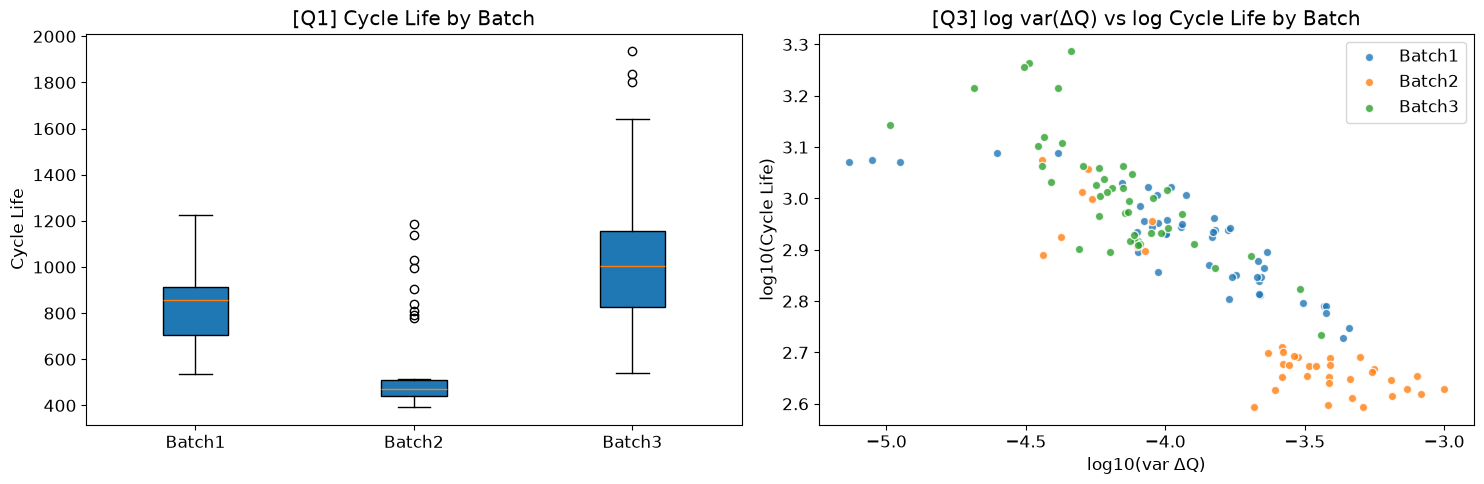

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].boxplot([ac[ac.batch == b]['cycle_life'] for b in colors], tick_labels=list(colors), patch_artist=True)
axes[0].set_title('[Q1] Cycle Life by Batch'); axes[0].set_ylabel('Cycle Life')
for b, c in colors.items():
    g = ac[ac.batch == b]
    axes[1].scatter(g['log_dq_var'], g['log_life'], color=c, label=b, edgecolors='white', alpha=0.8)
axes[1].set_xlabel('log10(var ΔQ)'); axes[1].set_ylabel('log10(Cycle Life)')
axes[1].set_title('[Q3] log var(ΔQ) vs log Cycle Life by Batch'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.